# Dispatch Optimization Model &mdash; VelozMart Logistics

Toy-model simulation of a priority-queue dispatch system for order logistics.
Optimizes scoring weights (`W1`, `W2`, `W3`) and size bonuses (`n`, `m`) via grid search.

In [1]:
# Cell 1: Imports &amp; Configuration

import heapq
import itertools
import math
import random
from dataclasses import dataclass
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# Global configuration
# ---------------------------------------------------------------------------
CONFIG = {
    # Orders simulation
    'N_ORDERS': 800,
    'SIMULATION_DURATION': 480,          # minutes (4 hours)
    'ORDER_ARRIVAL_RATE': None,          # auto-computed as N_ORDERS / SIMULATION_DURATION
    'DISPATCH_CAPACITY': 2,              # orders dispatched per minute

    # Heap rebuild timing
    'HEAP_REBUILD_MIN': 2,               # minutes between rebuilds (minimum)
    'HEAP_REBUILD_MAX': 3,               # minutes between rebuilds (maximum)

    # Order generation ranges
    'DISPATCH_WINDOW_MIN': 10,
    'DISPATCH_WINDOW_MAX': 120,
    'PRIORITY_MIN': 0,
    'PRIORITY_MAX': 100,
    'SIZE_CATEGORIES': ['P', 'M', 'G'],
    'SIZE_WEIGHTS': [0.2, 0.3, 0.5],

    # Grid search parameter space
    'W1_GRID': [0.1, 0.5, 1.0, 2.0, 5.0],
    'W2_GRID': [0.1, 0.5, 1.0, 2.0, 5.0],
    'W3_GRID': [0.1, 0.5, 1.0, 2.0, 5.0],   # weight for overdue penalty
    'N_GRID': [5, 10, 20, 30],           # bonus for size P
    'M_GRID': [3, 7, 15, 20],            # bonus for size M

    # Reproducibility
    'RANDOM_SEED': 42,
}

# Auto-compute arrival rate for the Poisson process
CONFIG['ORDER_ARRIVAL_RATE'] = CONFIG['N_ORDERS'] / CONFIG['SIMULATION_DURATION']

# Seed RNGs for reproducibility
np.random.seed(CONFIG['RANDOM_SEED'])
random.seed(CONFIG['RANDOM_SEED'])

print(f"Order arrival rate (lambda): {CONFIG['ORDER_ARRIVAL_RATE']:.2f} orders/min")
print(f"Expected total orders: ~{CONFIG['N_ORDERS']}")
print(f"Simulation window: {CONFIG['SIMULATION_DURATION']} minutes")
print(f"Dispatch capacity: {CONFIG['DISPATCH_CAPACITY']} orders/min")

Order arrival rate (lambda): 1.67 orders/min
Expected total orders: ~800
Simulation window: 480 minutes
Dispatch capacity: 2 orders/min


In [2]:
# Cell 2: Synthetic Data Generation
# ---------------------------------------------------------------------------
# Generate orders arriving via a Poisson process.  Each order receives:
#   - arrival_time  : cumulative exponential inter-arrival times
#   - priority_score: uniform [0, 100]
#   - dispatch_window: uniform [DISPATCH_WINDOW_MIN, DISPATCH_WINDOW_MAX]  -- ALWAYS POSITIVE
#   - size_category : random choice from ['P', 'M', 'G'] with weights
# ---------------------------------------------------------------------------

rate = CONFIG['ORDER_ARRIVAL_RATE']

# Generate slightly more arrivals than needed, then truncate
overgenerate_factor = 1.5
n_candidates = int(CONFIG['N_ORDERS'] * overgenerate_factor)

# Poisson process: inter-arrival times ~ Exponential(1/rate)
inter_arrivals = np.random.exponential(scale=1.0 / rate, size=n_candidates)
arrival_times = np.cumsum(inter_arrivals)

# Truncate to SIMULATION_DURATION, keep exactly N_ORDERS
within_window = arrival_times <= CONFIG['SIMULATION_DURATION']
arrival_times = arrival_times[within_window][:CONFIG['N_ORDERS']]

# If we got fewer than N_ORDERS, pad with late arrivals
actual_n = len(arrival_times)
if actual_n < CONFIG['N_ORDERS']:
    extra = np.random.uniform(0, CONFIG['SIMULATION_DURATION'], CONFIG['N_ORDERS'] - actual_n)
    arrival_times = np.concatenate([arrival_times, extra])

# Build DataFrame
orders_df = pd.DataFrame({
    'order_id': range(CONFIG['N_ORDERS']),
    'arrival_time': arrival_times,
    'priority_score': np.random.randint(CONFIG['PRIORITY_MIN'], CONFIG['PRIORITY_MAX'] + 1, CONFIG['N_ORDERS']),
    'dispatch_window': np.random.randint(CONFIG['DISPATCH_WINDOW_MIN'], CONFIG['DISPATCH_WINDOW_MAX'] + 1, CONFIG['N_ORDERS']),
    'size_category': np.random.choice(CONFIG['SIZE_CATEGORIES'], CONFIG['N_ORDERS'], p=CONFIG['SIZE_WEIGHTS']),
})

# Sort by arrival time
orders_df = orders_df.sort_values('arrival_time').reset_index(drop=True)
orders_df['order_id'] = range(CONFIG['N_ORDERS'])

print(f"Generated {len(orders_df)} orders")
print()
print("First 10 orders:")
display(orders_df.head(10))
print()
print("Summary statistics:")
display(orders_df.describe())
print()
print("Size category distribution:")
display(orders_df['size_category'].value_counts())

Generated 800 orders

First 10 orders:


,order_id,arrival_time,priority_score,dispatch_window,size_category
0,0,0.281561,75,54,G
1,1,2.087634,6,69,P
2,2,2.877681,28,21,G
3,3,3.425447,10,41,M
4,4,3.527222,32,105,G
5,5,3.628979,5,101,P
6,6,3.664883,78,22,P
7,7,4.871621,31,40,G
8,8,5.423070,50,87,M
9,9,6.161820,74,29,G



Summary statistics:


,order_id,arrival_time,priority_score,dispatch_window
count,800.0000,800.000000,800.000000,800.000000
mean,399.5000,238.066459,48.225000,63.751250
std,231.0844,141.357980,29.173459,33.023326
min,0.0000,0.281561,0.000000,10.000000
25%,199.7500,113.920667,23.000000,33.000000
50%,399.5000,232.269882,46.000000,64.000000
75%,599.2500,370.329202,74.000000,94.000000
max,799.0000,478.371234,100.000000,120.000000



Size category distribution:


size_category
G    398
M    248
P    154
Name: count, dtype: int64

In [3]:
# Cell 3: Core Data Structures &amp; Scoring Engine
# ---------------------------------------------------------------------------
# Order dataclass: the canonical representation of a logistics order.
# ScoringEngine: computes the dynamicScore via piecewise function.
# DoubleBufferHeap: concurrent-style max-heap with atomic shadow swap.
# ---------------------------------------------------------------------------

@dataclass
class Order:
    """Canonical order representation.  dispatch_window is always positive at birth."""
    order_id: int
    priority_score: int
    dispatch_window: int       # remaining time; decreases over simulation; never zero
    size_category: str         # 'P', 'M', or 'G'
    arrival_time: float
    insert_time: float = 0.0
    dispatch_time: Optional[float] = None
    expired_time: Optional[float] = None   # minute at which dw crossed below zero
    is_expired: bool = False


class ScoringEngine:
    """Computes dynamicScore for max-heap ordering.

    Piecewise formula:
      dispatch_window > 0:  W1 * priority + W2 * (1 / dispatchWindow) + sizeBonus
      dispatch_window < 0:  W1 * priority + sizeBonus + W3 * (-dispatchWindow)
        (more-negative dw gives higher score &mdash; pushes overdue orders to top)
    """

    def __init__(self, w1: float, w2: float, w3: float, bonus_n: int, bonus_m: int):
        self.w1 = w1
        self.w2 = w2
        self.w3 = w3
        self.bonus_n = bonus_n
        self.bonus_m = bonus_m

    def get_size_bonus(self, size_category: str) -> int:
        if size_category == 'P':
            return self.bonus_n
        if size_category == 'M':
            return self.bonus_m
        return 0  # 'G'

    def compute_dynamic_score(self, order: Order) -> float:
        """Return the dynamic score for heap ordering (higher = dispatched sooner)."""
        size_bonus = self.get_size_bonus(order.size_category)
        dw = order.dispatch_window

        if dw > 0:
            return (self.w1 * order.priority_score) + (self.w2 * (1.0 / dw)) + size_bonus

        # dw < 0: overdue &mdash; more negative is more urgent
        return (self.w1 * order.priority_score) + size_bonus + (self.w3 * (-dw))


class DoubleBufferHeap:
    """Max-heap with atomic double-buffer swap for concurrency-safe rebuilds.

    Uses Python's heapq (min-heap) with negated scores for max-heap behavior.
    The _active heap serves reads/dispatches while _shadow is rebuilt offline.
    """

    def __init__(self, scoring_engine: ScoringEngine):
        self._active: list = []      # tuples of (-score, order_id, order)
        self._shadow: list = []
        self._scoring = scoring_engine

    def push_active(self, order: Order) -> None:
        """Push an order onto the active heap with a fresh score."""
        score = self._scoring.compute_dynamic_score(order)
        heapq.heappush(self._active, (-score, order.order_id, order))

    def pop_active(self) -> Optional[Order]:
        """Remove and return the maximum-score order from the active heap."""
        if not self._active:
            return None
        return heapq.heappop(self._active)[2]

    def active_size(self) -> int:
        return len(self._active)

    def prepare_rebuild(self, orders: list[Order]) -> None:
        """Rebuild the shadow heap with recalculated scores for every order."""
        self._shadow = []
        for order in orders:
            score = self._scoring.compute_dynamic_score(order)
            heapq.heappush(self._shadow, (-score, order.order_id, order))

    def swap(self) -> None:
        """Atomically swap active and shadow heaps so reads never see partial state."""
        self._active, self._shadow = self._shadow, self._active
        self._shadow = []

In [4]:
# Cell 4: Simulation Engine
# ---------------------------------------------------------------------------
# Refactored design: the DoubleBufferHeap IS the order queue.
# No separate `queued_orders` list &mdash; orders live exclusively in the heap.
#
# Each simulation minute:
#   1. Decrement dispatchWindow on all active-heap orders (mutate in-place).
#      If dw hits 0, force to -1 and mark expired.
#   2. Push new arrivals directly into the active heap.
#   3. If it is a rebuild minute: collect active orders, recalculate scores
#      into the shadow heap, then swap &mdash; restoring heap invariant.
#   4. Dispatch up to DISPATCH_CAPACITY orders (pop max-score from active).
# ---------------------------------------------------------------------------

def run_simulation(orders_df: pd.DataFrame, w1: float, w2: float, w3: float,
                   bonus_n: int, bonus_m: int, config: dict):
    """Run the dispatch simulation and return a metrics-rich result dict."""

    scoring = ScoringEngine(w1, w2, w3, bonus_n, bonus_m)
    heap = DoubleBufferHeap(scoring)

    # Convert DataFrame rows into Order objects, sorted by arrival_time
    pending_arrivals = sorted([
        Order(
            order_id=row['order_id'],
            priority_score=int(row['priority_score']),
            dispatch_window=int(row['dispatch_window']),
            size_category=str(row['size_category']),
            arrival_time=float(row['arrival_time']),
        )
        for _, row in orders_df.iterrows()
    ], key=lambda o: o.arrival_time)

    arrival_idx = 0
    dispatched: list[Order] = []
    expired: list[Order] = []

    # First rebuild happens after a random delay, NOT at t=0
    next_rebuild_time = random.randint(
        config['HEAP_REBUILD_MIN'], config['HEAP_REBUILD_MAX'])

    for t in range(config['SIMULATION_DURATION'] + 1):
        # ---- 1. Decrement dispatch window on all queued orders ---------------
        for _, _, order in heap._active:
            if order.is_expired:
                continue
            order.dispatch_window -= 1
            if order.dispatch_window == 0:
                order.dispatch_window = -1
                order.expired_time = t
                order.is_expired = True

        # ---- 2. Insert new arrivals -----------------------------------------
        while (arrival_idx < len(pending_arrivals)
               and pending_arrivals[arrival_idx].arrival_time <= t):
            new_order = pending_arrivals[arrival_idx]
            new_order.insert_time = t
            heap.push_active(new_order)
            arrival_idx += 1

        # ---- 3. Periodic heap rebuild (every 2-3 minutes) -------------------
        if t >= next_rebuild_time:
            active_orders = [order for _, _, order in heap._active]
            heap.prepare_rebuild(active_orders)
            heap.swap()
            next_rebuild_time = t + random.randint(
                config['HEAP_REBUILD_MIN'], config['HEAP_REBUILD_MAX'])

        # ---- 4. Dispatch phase ----------------------------------------------
        for _ in range(config['DISPATCH_CAPACITY']):
            order = heap.pop_active()
            if order is None:
                break

            order.dispatch_time = t
            dispatched.append(order)

            if order.is_expired:
                expired.append(order)

    # ---- Post-simulation: any order still in heap is expired ----------------
    for _, _, order in heap._active:
        if not order.is_expired:
            order.is_expired = True
            order.expired_time = config['SIMULATION_DURATION']
        expired.append(order)

    return {'dispatched': dispatched, 'expired': expired}


# Quick smoke test with the default orders
print("Running smoke test with W1=1.0 W2=1.0 W3=1.0 n=10 m=7 ...")
test_result = run_simulation(orders_df, w1=1.0, w2=1.0, w3=1.0, bonus_n=10, bonus_m=7, config=CONFIG)
print(f"  Dispatched: {len(test_result['dispatched'])}")
print(f"  Expired:    {len(test_result['expired'])}")

Running smoke test with W1=1.0 W2=1.0 W3=1.0 n=10 m=7 ...
  Dispatched: 800
  Expired:    6


In [5]:
# Cell 5: Metrics Tracking
# ---------------------------------------------------------------------------
# Compute performance KPIs from a simulation result.
# The composite score drives the grid-search optimisation:
#   lower = better (penalises expired orders, rewards throughput &amp; priority).
# ---------------------------------------------------------------------------

def compute_metrics(sim_result: dict, config: dict):
    """Derive scalar KPIs from a simulation result."""

    dispatched = sim_result['dispatched']
    expired = sim_result['expired']

    expired_count = len(expired)

    # Average delay for expired orders: (dispatchTime - expiredTime)
    if expired_count > 0:
        delays = [
            o.dispatch_time - o.expired_time
            for o in expired
            if o.dispatch_time is not None and o.expired_time is not None
        ]
        avg_delay = float(np.mean(delays)) if delays else 0.0
    else:
        avg_delay = 0.0

    # Throughput (orders dispatched per minute)
    throughput = len(dispatched) / config['SIMULATION_DURATION']

    # Average dispatch time: (dispatchTime - arrivalTime)
    if dispatched:
        dispatch_times = [
            o.dispatch_time - o.arrival_time
            for o in dispatched
            if o.dispatch_time is not None
        ]
        avg_dispatch_time = float(np.mean(dispatch_times)) if dispatch_times else 0.0
    else:
        avg_dispatch_time = 0.0

    # Average priority score among dispatched orders
    if dispatched:
        avg_priority = float(np.mean([o.priority_score for o in dispatched]))
    else:
        avg_priority = 0.0

    # Composite score (LOWER = BETTER)
    # Heavily penalise expirations, reward throughput and high-priority dispatch
    composite = (
        expired_count * 10.0
        + avg_delay * 2.0
        - throughput * 100.0
        - avg_priority * 0.5
    )

    return {
        'expired_count': expired_count,
        'avg_delay': avg_delay,
        'throughput': throughput,
        'avg_dispatch_time': avg_dispatch_time,
        'avg_priority': avg_priority,
        'composite': composite,
    }


# Verify on the smoke-test result
test_metrics = compute_metrics(test_result, CONFIG)
print("Smoke-test metrics:")
for k, v in test_metrics.items():
    print(f"  {k:>20s}: {v:.2f}" if isinstance(v, float) else f"  {k:>20s}: {v}")

Smoke-test metrics:
         expired_count: 6
             avg_delay: 12.50
            throughput: 1.67
     avg_dispatch_time: 2.25
          avg_priority: 48.23
             composite: -105.78


In [6]:
# Cell 6: Grid Search Optimisation
# ---------------------------------------------------------------------------
# Exhaustively evaluate every (W1, W2, W3, n, m) combination in the grid.
# Track the best composite score and report optimal parameters.
# ---------------------------------------------------------------------------

def grid_search(orders_df: pd.DataFrame, config: dict):
    """Evaluate all parameter combinations; return a DataFrame of results."""

    w1_grid = config['W1_GRID']
    w2_grid = config['W2_GRID']
    w3_grid = config['W3_GRID']
    n_grid = config['N_GRID']
    m_grid = config['M_GRID']

    total = len(w1_grid) * len(w2_grid) * len(w3_grid) * len(n_grid) * len(m_grid)

    results = []
    count = 0

    for w1 in w1_grid:
        for w2 in w2_grid:
            for w3 in w3_grid:
                for n in n_grid:
                    for m in m_grid:
                        count += 1
                        sim_result = run_simulation(orders_df, w1, w2, w3, n, m, config)
                        metrics = compute_metrics(sim_result, config)
                        results.append({
                            'W1': w1, 'W2': w2, 'W3': w3, 'n': n, 'm': m,
                            **metrics,
                        })

                        if count % 100 == 0:
                            print(f"  Progress: {count}/{total}")

    return pd.DataFrame(results)


# ---- Execute grid search ----------------------------------------------------
print("Running grid search ...")
results_df = grid_search(orders_df, CONFIG)

# Identify the parameter set with the LOWEST composite score
best_idx = results_df['composite'].idxmin()
best = results_df.iloc[best_idx]

print()
print("=" * 56)
print("  GRID SEARCH RESULTS")
print("=" * 56)
print(f"  Combinations tested: {len(results_df)}")
print()
print(f"  Best parameters:")
print(f"    W1 = {best['W1']}")
print(f"    W2 = {best['W2']}")
print(f"    W3 = {best['W3']}")
print(f"    n  = {int(best['n'])}")
print(f"    m  = {int(best['m'])}")
print()
print(f"  Best metrics:")
print(f"    Expired orders:       {int(best['expired_count'])}")
print(f"    Avg delay:            {best['avg_delay']:.2f} min")
print(f"    Throughput:           {best['throughput']:.2f} orders/min")
print(f"    Avg dispatch time:    {best['avg_dispatch_time']:.2f} min")
print(f"    Avg priority dispatched: {best['avg_priority']:.2f} / 100")
print(f"    Composite score:      {best['composite']:.2f}")
print("=" * 56)

Running grid search ...
  Progress: 100/2000
  Progress: 200/2000
  Progress: 300/2000
  Progress: 400/2000
  Progress: 500/2000
  Progress: 600/2000
  Progress: 700/2000
  Progress: 800/2000
  Progress: 900/2000
  Progress: 1000/2000
  Progress: 1100/2000
  Progress: 1200/2000
  Progress: 1300/2000
  Progress: 1400/2000
  Progress: 1500/2000
  Progress: 1600/2000
  Progress: 1700/2000
  Progress: 1800/2000
  Progress: 1900/2000
  Progress: 2000/2000

  GRID SEARCH RESULTS
  Combinations tested: 2000

  Best parameters:
    W1 = 0.1
    W2 = 5.0
    W3 = 0.1
    n  = 5
    m  = 3

  Best metrics:
    Expired orders:       1
    Avg delay:            0.00 min
    Throughput:           1.67 orders/min
    Avg dispatch time:    2.25 min
    Avg priority dispatched: 48.23 / 100
    Composite score:      -180.78


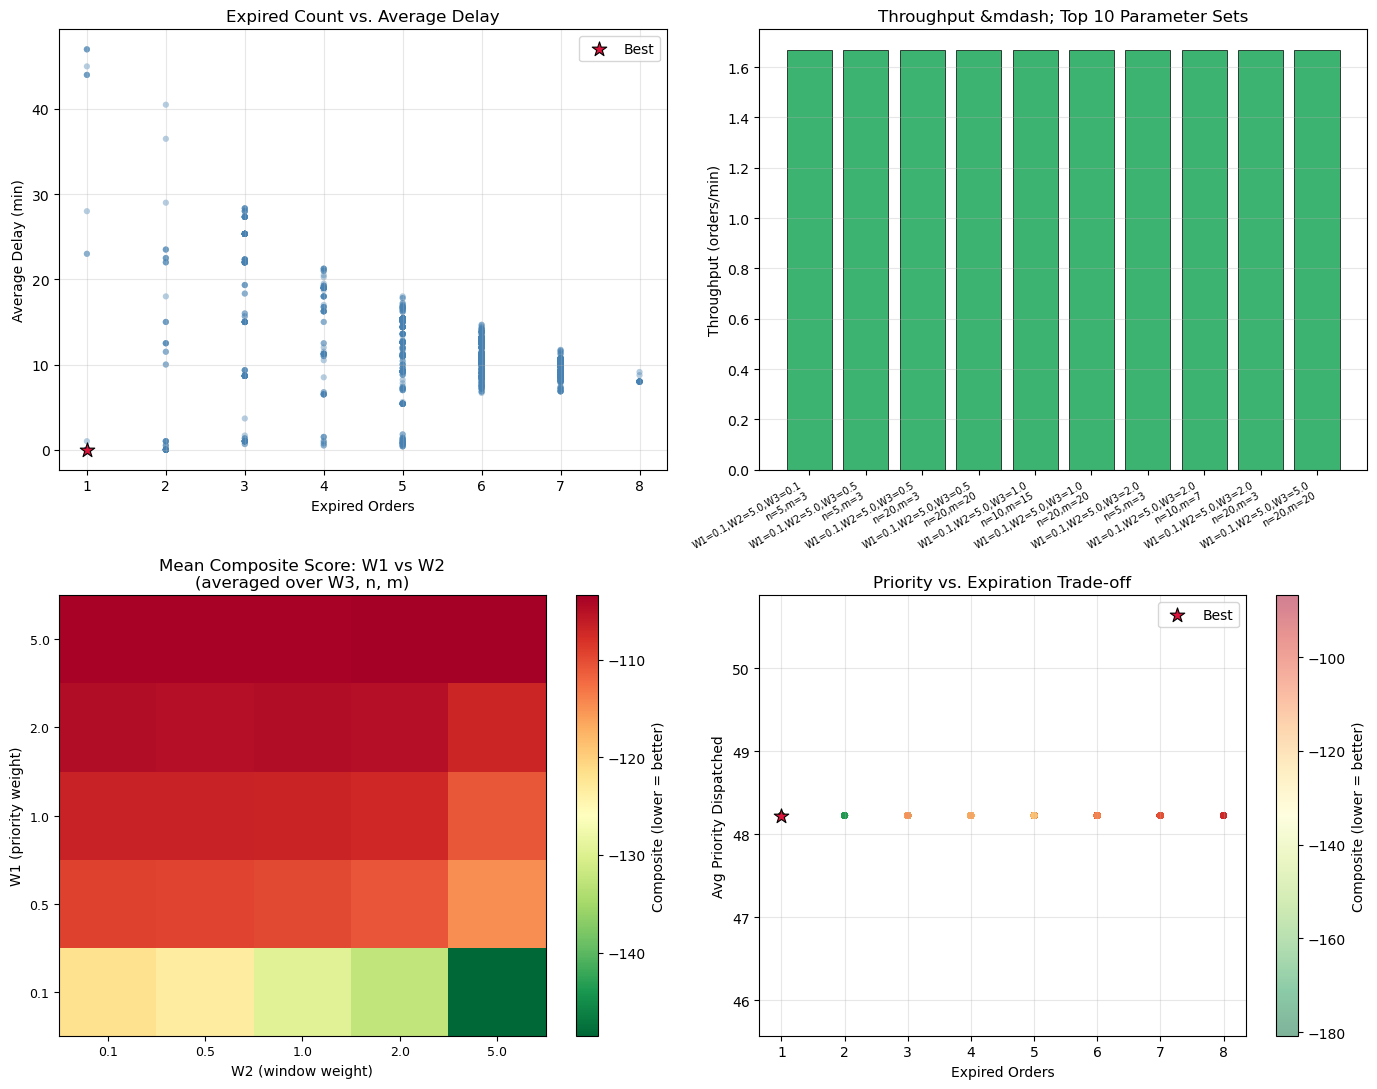

In [7]:
# Cell 7: Visualisation
# ---------------------------------------------------------------------------
# 2&amp;times;2 subplot grid exploring the optimisation landscape.
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# ---- Top-left: expired_count vs avg_delay (all combos) ---------------------
ax = axes[0, 0]
ax.scatter(results_df['expired_count'], results_df['avg_delay'],
           alpha=0.4, s=20, c='steelblue', edgecolors='none')
ax.scatter(best['expired_count'], best['avg_delay'],
           color='crimson', s=120, marker='*', edgecolors='black', linewidths=0.8,
           zorder=5, label='Best')
ax.set_xlabel('Expired Orders')
ax.set_ylabel('Average Delay (min)')
ax.set_title('Expired Count vs. Average Delay')
ax.legend()
ax.grid(True, alpha=0.3)

# ---- Top-right: throughput for top-10 parameter sets -----------------------
ax = axes[0, 1]
top10 = results_df.nsmallest(10, 'composite').copy()
bar_labels = [
    f"W1={r['W1']},W2={r['W2']},W3={r['W3']}\nn={int(r['n'])},m={int(r['m'])}"
    for _, r in top10.iterrows()
]
bars = ax.bar(range(len(top10)), top10['throughput'],
              color='mediumseagreen', edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(top10)))
ax.set_xticklabels(bar_labels, rotation=30, ha='right', fontsize=7)
ax.set_ylabel('Throughput (orders/min)')
ax.set_title('Throughput &mdash; Top 10 Parameter Sets')
ax.grid(True, axis='y', alpha=0.3)

# ---- Bottom-left: heatmap of composite score (W1 vs W2, avg over W3, n, m) ----
ax = axes[1, 0]
heatmap_data = results_df.groupby(['W1', 'W2'])['composite'].mean().unstack()
im = ax.imshow(heatmap_data.values, aspect='auto', origin='lower',
               cmap='RdYlGn_r')
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, fontsize=9)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=9)
ax.set_xlabel('W2 (window weight)')
ax.set_ylabel('W1 (priority weight)')
ax.set_title('Mean Composite Score: W1 vs W2\n(averaged over W3, n, m)')
fig.colorbar(im, ax=ax, label='Composite (lower = better)')

# ---- Bottom-right: avg_priority vs expired_count (trade-off) ---------------
ax = axes[1, 1]
sc = ax.scatter(results_df['expired_count'], results_df['avg_priority'],
                c=results_df['composite'], cmap='RdYlGn_r', alpha=0.5, s=25,
                edgecolors='none')
ax.scatter(best['expired_count'], best['avg_priority'],
           color='crimson', s=120, marker='*', edgecolors='black', linewidths=0.8,
           zorder=5, label='Best')
ax.set_xlabel('Expired Orders')
ax.set_ylabel('Avg Priority Dispatched')
ax.set_title('Priority vs. Expiration Trade-off')
ax.legend()
ax.grid(True, alpha=0.3)
fig.colorbar(sc, ax=ax, label='Composite (lower = better)')

plt.tight_layout()
plt.show()

In [8]:
# Cell 8: Best-Model Execution Block
# ---------------------------------------------------------------------------
# Re-seed RNGs for reproducibility, then run the optimal parameters one
# final time and print a detailed report.
# ---------------------------------------------------------------------------

best_w1 = best['W1']
best_w2 = best['W2']
best_w3 = best['W3']
best_n = int(best['n'])
best_m = int(best['m'])

# Reproducibility: re-seed before final run
np.random.seed(CONFIG['RANDOM_SEED'])
random.seed(CONFIG['RANDOM_SEED'])

final_result = run_simulation(orders_df, best_w1, best_w2, best_w3, best_n, best_m, CONFIG)
final_metrics = compute_metrics(final_result, CONFIG)

print("=" * 60)
print("  FINAL MODEL REPORT &mdash; VelozMart Dispatch Optimization")
print("=" * 60)
print()
print("Parameters:")
print(f"  W1 (priority weight):     {best_w1}")
print(f"  W2 (window weight):       {best_w2}")
print(f"  W3 (overdue weight):      {best_w3}")
print(f"  n  (size P bonus):        {best_n}")
print(f"  m  (size M bonus):        {best_m}")
print(f"  G  bonus:                 0")
print()
print("Performance Metrics:")
print(f"  Expired orders:           {final_metrics['expired_count']}")
print(f"  Average delay time:       {final_metrics['avg_delay']:.2f} min")
print(f"  Throughput:               {final_metrics['throughput']:.2f} orders/min")
print(f"  Average dispatch time:    {final_metrics['avg_dispatch_time']:.2f} min")
print(f"  Avg priority dispatched:  {final_metrics['avg_priority']:.2f} / 100")
print(f"  Composite score:          {final_metrics['composite']:.2f}")
print()
print(f"Total dispatched: {len(final_result['dispatched'])}")
print(f"Total expired:    {len(final_result['expired'])}")
print("=" * 60)

  FINAL MODEL REPORT &mdash; VelozMart Dispatch Optimization

Parameters:
  W1 (priority weight):     0.1
  W2 (window weight):       5.0
  W3 (overdue weight):      0.1
  n  (size P bonus):        5
  m  (size M bonus):        3
  G  bonus:                 0

Performance Metrics:
  Expired orders:           3
  Average delay time:       3.67 min
  Throughput:               1.67 orders/min
  Average dispatch time:    2.25 min
  Avg priority dispatched:  48.23 / 100
  Composite score:          -153.45

Total dispatched: 800
Total expired:    3


In [9]:
# Cell 9: Comprehensive Summary

print("\n" + "=" * 60)
print("  COMPREHENSIVE OPTIMIZATION SUMMARY")
print("=" * 60)

# ---------------------------------------------------------------------------
# 1. INPUT PARAMETERS
# ---------------------------------------------------------------------------
print()
print("1. INPUT PARAMETERS")
print("-" * 40)
print(f"  N_ORDERS:              {CONFIG['N_ORDERS']}")
print(f"  SIMULATION_DURATION:   {CONFIG['SIMULATION_DURATION']} min")
print(f"  DISPATCH_CAPACITY:     {CONFIG['DISPATCH_CAPACITY']} orders/min")
print(f"  ORDER_ARRIVAL_RATE:    {CONFIG['ORDER_ARRIVAL_RATE']:.2f} orders/min")
print(f"  HEAP_REBUILD_RANGE:    [{CONFIG['HEAP_REBUILD_MIN']}, {CONFIG['HEAP_REBUILD_MAX']}] min")
print(f"  DISPATCH_WINDOW_RANGE: [{CONFIG['DISPATCH_WINDOW_MIN']}, {CONFIG['DISPATCH_WINDOW_MAX']}]")
print(f"  PRIORITY_RANGE:        [{CONFIG['PRIORITY_MIN']}, {CONFIG['PRIORITY_MAX']}]")
print(f"  SIZE_CATEGORIES:       {CONFIG['SIZE_CATEGORIES']}  (weights: {CONFIG['SIZE_WEIGHTS']})")
print(f"  RANDOM_SEED:           {CONFIG['RANDOM_SEED']}")
print(f"  Grid search space:")
print(f"    W1_grid:  {len(CONFIG['W1_GRID'])} values  {CONFIG['W1_GRID']}")
print(f"    W2_grid:  {len(CONFIG['W2_GRID'])} values  {CONFIG['W2_GRID']}")
print(f"    W3_grid:  {len(CONFIG['W3_GRID'])} values  {CONFIG['W3_GRID']}")
print(f"    n_grid:   {len(CONFIG['N_GRID'])} values  {CONFIG['N_GRID']}")
print(f"    m_grid:   {len(CONFIG['M_GRID'])} values  {CONFIG['M_GRID']}")
total_combos = len(CONFIG['W1_GRID']) * len(CONFIG['W2_GRID']) * len(CONFIG['W3_GRID']) * len(CONFIG['N_GRID']) * len(CONFIG['M_GRID'])
print(f"    Total combinations:  {total_combos}")

# ---------------------------------------------------------------------------
# 2. FINAL SCORING EQUATION
# ---------------------------------------------------------------------------
print()
print("2. FINAL SCORING EQUATION")
print("-" * 40)
best_w1 = best['W1']
best_w2 = best['W2']
best_w3 = best['W3']
best_n = int(best['n'])
best_m = int(best['m'])
print(f"  For dispatchWindow > 0:")
print(f"    dynamicScore = (W1 * priorityScore) + (W2 * (1 / dispatchWindow)) + sizeBonus")
print(f"                 = ({best_w1} * priorityScore) + ({best_w2} * (1 / dispatchWindow)) + sizeBonus")
print()
print(f"  For dispatchWindow < 0:")
print(f"    dynamicScore = (W1 * priorityScore) + sizeBonus + (W3 * (-dispatchWindow))")
print(f"                 = ({best_w1} * priorityScore) + sizeBonus + ({best_w3} * (-dispatchWindow))")
print()
print(f"  Where sizeBonus = {best_n} for P, {best_m} for M, 0 for G")

# ---------------------------------------------------------------------------
# 3. PERFORMANCE METRICS SUMMARY
# ---------------------------------------------------------------------------
print()
print("3. PERFORMANCE METRICS SUMMARY")
print("-" * 40)
total_orders = len(final_result['dispatched']) + len(final_result['expired'])
expired_count = final_metrics['expired_count']
print(f"  Expired orders:                {expired_count}")
print(f"  Average delay time:            {final_metrics['avg_delay']:.2f} min")
print(f"  Throughput:                    {final_metrics['throughput']:.2f} orders/min")
print(f"  Average dispatch time:         {final_metrics['avg_dispatch_time']:.2f} min")
print(f"  Avg priority of dispatched:    {final_metrics['avg_priority']:.2f} / 100")
print(f"  Composite score:               {final_metrics['composite']:.2f}")
print(f"  Total dispatched:              {len(final_result['dispatched'])}")
print(f"  Total orders:                  {total_orders}")
print(f"  Expiration rate:               {expired_count / total_orders * 100:.2f}%")

# ---------------------------------------------------------------------------
# 4. COMPOSITE SCORE FORMULA
# ---------------------------------------------------------------------------
print()
print("4. COMPOSITE SCORE FORMULA")
print("-" * 40)
print(f"  composite = expired_count * 10 + avg_delay * 2 - throughput * 100 - avg_priority * 0.5")
print(f"  composite = {expired_count} * 10 + {final_metrics['avg_delay']:.2f} * 2 - {final_metrics['throughput']:.2f} * 100 - {final_metrics['avg_priority']:.2f} * 0.5")
print(f"  composite = {final_metrics['composite']:.2f}")
print()
print("=" * 60)



  COMPREHENSIVE OPTIMIZATION SUMMARY

1. INPUT PARAMETERS
----------------------------------------
  N_ORDERS:              800
  SIMULATION_DURATION:   480 min
  DISPATCH_CAPACITY:     2 orders/min
  ORDER_ARRIVAL_RATE:    1.67 orders/min
  HEAP_REBUILD_RANGE:    [2, 3] min
  DISPATCH_WINDOW_RANGE: [10, 120]
  PRIORITY_RANGE:        [0, 100]
  SIZE_CATEGORIES:       ['P', 'M', 'G']  (weights: [0.2, 0.3, 0.5])
  RANDOM_SEED:           42
  Grid search space:
    W1_grid:  5 values  [0.1, 0.5, 1.0, 2.0, 5.0]
    W2_grid:  5 values  [0.1, 0.5, 1.0, 2.0, 5.0]
    W3_grid:  5 values  [0.1, 0.5, 1.0, 2.0, 5.0]
    n_grid:   4 values  [5, 10, 20, 30]
    m_grid:   4 values  [3, 7, 15, 20]
    Total combinations:  2000

2. FINAL SCORING EQUATION
----------------------------------------
  For dispatchWindow > 0:
    dynamicScore = (W1 * priorityScore) + (W2 * (1 / dispatchWindow)) + sizeBonus
                 = (0.1 * priorityScore) + (5.0 * (1 / dispatchWindow)) + sizeBonus

  For dispatchWi